# Reto 2 – Análisis de luz

**Objetivo:** Explorar cómo la luz influye sobre la biomasa y otros parámetros.

Carga el conjunto de datos y explora las variables relevantes.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('../data/resultados_experimentos.csv')

df.head()

,sitio,temperatura,humedad,luz,biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8
1,Humedal Facatativá,18.0,89.7,395,225.8
2,Río San Francisco,17.2,85.4,647,237.5
3,Ladera de La Vega,21.7,81.4,769,252.4
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7


## Exploración inicial
Describe las columnas y analiza los tipos de datos.

In [9]:
def indice_luz(df):
    luz_max = df["luz"].max()
    df["indice_luz"] = df["luz"] / luz_max
    return df

In [10]:
df = indice_luz(df)
df.head()

,sitio,temperatura,humedad,luz,biomasa,indice_luz
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8,0.695007
1,Humedal Facatativá,18.0,89.7,395,225.8,0.266532
2,Río San Francisco,17.2,85.4,647,237.5,0.436572
3,Ladera de La Vega,21.7,81.4,769,252.4,0.518893
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7,0.899460


## Desarrollo del reto
Aplica funciones y análisis según el objetivo. Usa `def` para definir tus funciones.

In [11]:
def clasificar_luz(valor, p33, p66):
    if valor <= p33:
        return "baja"
    elif valor <= p66:
        return "media"
    else:
        return "alta"


In [12]:
p33 = df["luz"].quantile(0.33)
p66 = df["luz"].quantile(0.66)

df["categoria_luz"] = df["luz"].apply(lambda x: clasificar_luz(x, p33, p66))

df.head()

,sitio,temperatura,humedad,luz,biomasa,indice_luz,categoria_luz
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8,0.695007,alta
1,Humedal Facatativá,18.0,89.7,395,225.8,0.266532,baja
2,Río San Francisco,17.2,85.4,647,237.5,0.436572,baja
3,Ladera de La Vega,21.7,81.4,769,252.4,0.518893,baja
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7,0.899460,alta


In [13]:
tabla_biomasa = df.groupby("categoria_luz")["biomasa"].mean()

tabla_biomasa

categoria_luz
alta     201.071429
baja     164.642857
media    228.050000
Name: biomasa, dtype: float64

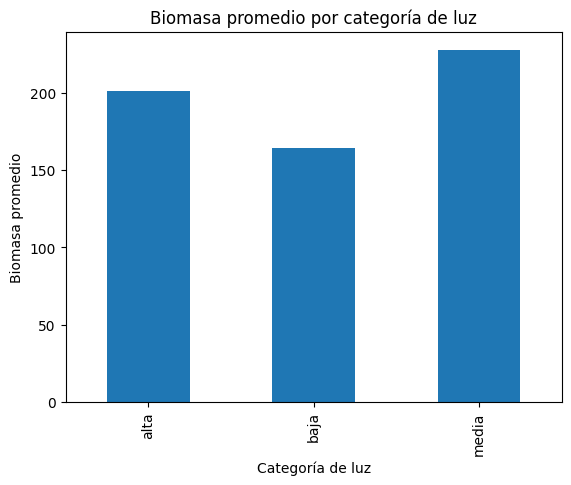

In [14]:
tabla_biomasa.plot(kind="bar")
plt.title("Biomasa promedio por categoría de luz")
plt.xlabel("Categoría de luz")
plt.ylabel("Biomasa promedio")
plt.show()

## Interpretación de resultados


Los resultados muestran que los sitios con mayor índice de luz tienden a presentar valores más altos de biomasa promedio, lo que puede estar relacionado con una mayor disponibilidad de energía para los procesos de fotosíntesis y productividad primaria. Por el contrario, los sitios con baja iluminación presentan menores niveles de biomasa, lo que podría limitar el crecimiento de la vegetación y afectar la dinámica del ecosistema.